# Interactive 3D Face Mapping

This module extracts the true 3D topography of your face (X, Y, and Z depth) and renders it as an interactive hologram.

**Instructions:**
1. Run all cells.
2. Select your photo when prompted.
3. Use your mouse to **drag, rotate, and zoom** the 3D face model directly inside the notebook!

# Install Plotly and Jupyter nbformat matplotlib directly into the active Jupyter kernel
import sys
!"{sys.executable}" -m pip install plotly nbformat matplotlib

In [42]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import plotly.graph_objects as go
import tkinter as tk
from tkinter import filedialog
import os
import urllib.request

# Ensure models and connections exist
MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task", 
        MODEL_PATH)

try:
    import face_mesh_connections as fmc
except ImportError:
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/google/mediapipe/master/mediapipe/python/solutions/face_mesh_connections.py",
        "face_mesh_connections.py"
    )
    import face_mesh_connections as fmc

# FULL DETAILED FACIAL FEATURES (Eyes, Eyebrows, Lips, Face Oval)
CONNECTIONS = [
    fmc.FACEMESH_LIPS,
    fmc.FACEMESH_LEFT_EYE,
    fmc.FACEMESH_LEFT_EYEBROW,
    fmc.FACEMESH_RIGHT_EYE,
    fmc.FACEMESH_RIGHT_EYEBROW,
    fmc.FACEMESH_FACE_OVAL,
    fmc.FACEMESH_NOSE
]


In [43]:
print("Please select your Face Photo for 3D mapping...")
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
USER_IMG_PATH = filedialog.askopenfilename(
    title="Select Photo",
    filetypes=[("Images", "*.png *.jpg *.jpeg")]
)
root.destroy()

if not USER_IMG_PATH:
    raise ValueError("No image selected.")

print(f"Selected: {USER_IMG_PATH}")


Please select your Face Photo for 3D mapping...
Selected: C:/Users/PratikJPatel/Downloads/360_F_276114144_xyAwCmx6IraojhvC2l9cNQEYAx6d28Nq.jpg


In [44]:
def extract_3d_landmarks(image_path):
    img = cv2.imread(image_path)
    if img is None: raise ValueError(f"Could not read {image_path}")
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        num_faces=1,
        min_face_detection_confidence=0.5,
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_image)
        if not result.face_landmarks:
            raise ValueError("No face detected in the image.")
        return result.face_landmarks[0]

landmarks = extract_3d_landmarks(USER_IMG_PATH)

# Calculate proportional depth scaling
import numpy as np
x_vals = [lm.x for lm in landmarks]
z_vals = [lm.z for lm in landmarks]
x_range = np.max(x_vals) - np.min(x_vals)
z_range = np.max(z_vals) - np.min(z_vals)

TARGET_Z_RANGE = x_range * 0.60
if z_range > 0:
    Z_MULTIPLIER = TARGET_Z_RANGE / z_range
else:
    Z_MULTIPLIER = 1.0

print(f"Dynamically scaled Z-depth by {Z_MULTIPLIER:.2f}x for perfect proportions.")


# Prepare data for Plotly 3D
import numpy as np

pts_3d = np.zeros((len(landmarks), 3))
for i, lm in enumerate(landmarks):
    pts_3d[i] = [lm.x, -lm.z * Z_MULTIPLIER, -lm.y]

# --- SYNTHETIC FOREHEAD GENERATION ---
import math
top_oval_indices = [21, 54, 103, 67, 109, 10, 338, 297, 332, 284, 251]
p_chin = pts_3d[152]
p_top = pts_3d[10]
# Calculate height using X and Z of plotly (which is the actual X and Y of face)
face_height = math.hypot(p_chin[0] - p_top[0], p_chin[2] - p_top[2])
center_x = p_top[0]

for idx in top_oval_indices:
    p = pts_3d[idx]
    sx = center_x + (p[0] - center_x) * 0.85
    sy = p[1] - (face_height * 0.1) # Push backward (Y is depth)
    sz = p[2] + (face_height * 0.22) # Push upward (Z is height)
    pts_3d[idx] = [sx, sy, sz]
# -------------------------------------

# --- CONTINUOUS SMOOTH CURVE ALGORITHMS ---
def order_edges(edges):
    adj = {}
    for u, v in edges:
        if u not in adj: adj[u] = []
        if v not in adj: adj[v] = []
        adj[u].append(v)
        adj[v].append(u)
        
    paths = []
    visited = set()
    
    for start_node in adj:
        if start_node in visited: continue
        
        curr = start_node
        for node in adj:
            if node not in visited and len(adj[node]) == 1:
                curr = node
                break
                
        path = [curr]
        visited.add(curr)
        
        while True:
            neighbors = [n for n in adj[curr] if n not in visited]
            if not neighbors: break
            curr = neighbors[0]
            path.append(curr)
            visited.add(curr)
            
        if len(adj[path[0]]) == 2 and len(adj[path[-1]]) == 2 and path[0] in adj[path[-1]]:
            path.append(path[0])
            
        paths.append(path)
    return paths

def chaikin_smooth(points, iterations=4, closed=False):
    if len(points) < 3: return points
    pts = np.array(points)
    for _ in range(iterations):
        if closed:
            p_next = np.roll(pts, -1, axis=0)
            pts_1 = 0.75 * pts + 0.25 * p_next
            pts_2 = 0.25 * pts + 0.75 * p_next
            new_pts = np.empty((pts.shape[0] * 2, pts.shape[1]))
            new_pts[0::2] = pts_1
            new_pts[1::2] = pts_2
            pts = new_pts
        else:
            p_next = pts[1:]
            pts_1 = 0.75 * pts[:-1] + 0.25 * p_next
            pts_2 = 0.25 * pts[:-1] + 0.75 * p_next
            new_pts = np.empty((len(pts_1) * 2, pts.shape[1]))
            new_pts[0::2] = pts_1
            new_pts[1::2] = pts_2
            pts = np.vstack([pts[0], new_pts, pts[-1]])
    return pts
# ----------------------------------------

# Prepare smooth wireframe traces
traces = []
for connection_set in CONNECTIONS:
    paths = order_edges(connection_set)
    for path in paths:
        is_closed = (path[0] == path[-1])
        path_coords = np.array([pts_3d[idx] for idx in path])
        smoothed = chaikin_smooth(path_coords, closed=is_closed)
        
        x = smoothed[:, 0]
        y = smoothed[:, 1]
        z = smoothed[:, 2]
        if is_closed:
            x = np.append(x, x[0])
            y = np.append(y, y[0])
            z = np.append(z, z[0])
            
        traces.append(go.Scatter3d(
            x=x, y=y, z=z,
            mode='lines',
            line=dict(color='#00e5ff', width=6),
            name='Facial Wireframe',
            showlegend=False
        ))

# Render the 3D Hologram
fig = go.Figure()

# 1. Add faint 3D point cloud
fig.add_trace(go.Scatter3d(
    x=pts_3d[:, 0], y=pts_3d[:, 1], z=pts_3d[:, 2],
    mode='markers',
    marker=dict(size=2.5, color='#ffffff', opacity=0.4),
    name='Mesh Points'
))

# 2. Add bold 3D smooth feature lines
for trace in traces:
    fig.add_trace(trace)

# Set dark theme and camera controls
fig.update_layout(
    title=dict(text="Interactive 3D Face Topography", font=dict(color='white', size=22)),
    scene=dict(
        xaxis=dict(visible=False, showbackground=False),
        yaxis=dict(visible=False, showbackground=False),
        zaxis=dict(visible=False, showbackground=False),
        aspectmode='data', 
        # Start camera slightly off-center to show depth immediately
        camera=dict(
            eye=dict(x=0.0, y=-1.5, z=0.0) # Look straight at the face from the front (Y is depth!)
        )
    ),
    paper_bgcolor='#0a0a0a',
    plot_bgcolor='#0a0a0a',
    margin=dict(l=0, r=0, b=0, t=60),
    showlegend=False,
)

# EXPORT TO BROWSER FOR GUARANTEED INTERACTIVITY
output_file = '3d_face_map.html'
print(f"Compiling 3D Model... Opening in your web browser: {output_file}")
fig.write_html(output_file, auto_open=True)

Dynamically scaled Z-depth by 0.80x for perfect proportions.
Compiling 3D Model... Opening in your web browser: 3d_face_map.html


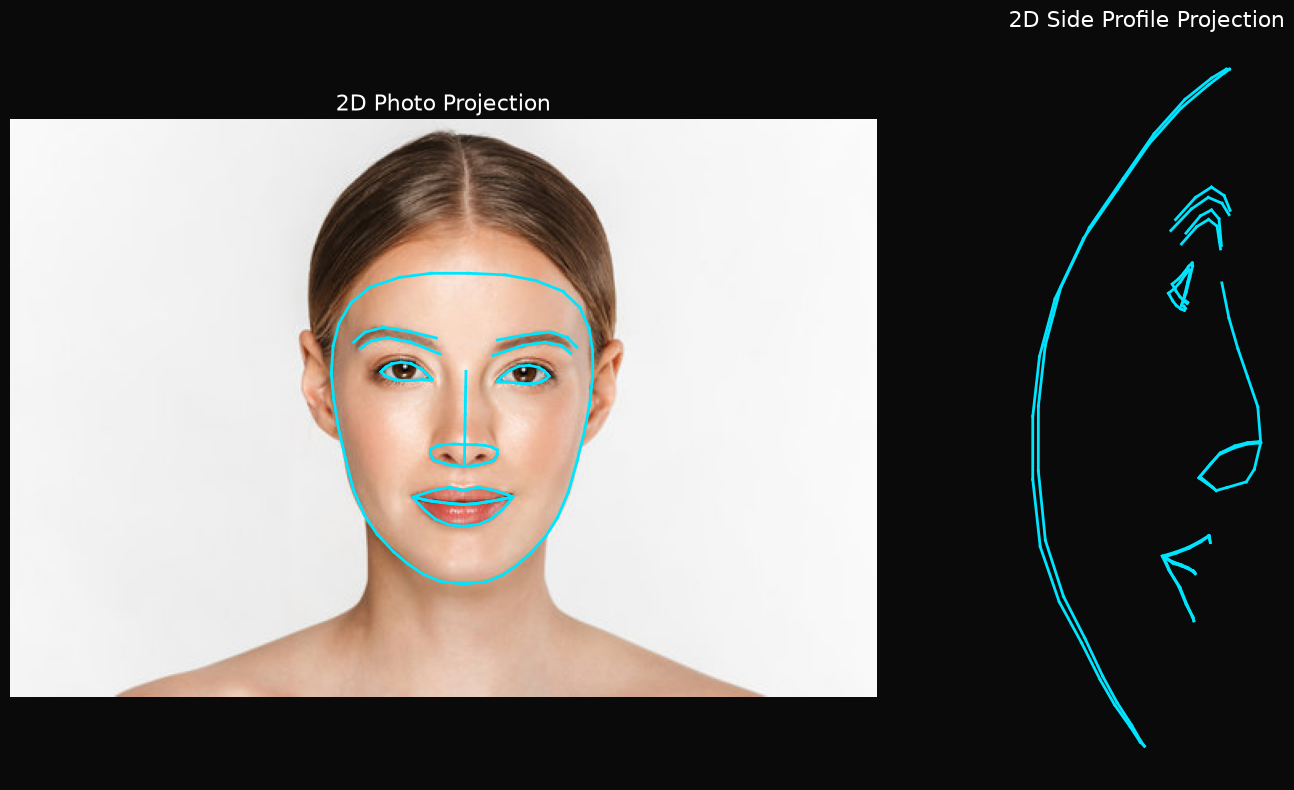

In [45]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Draw the 3D Face Mapping projected onto 2D Planes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0a0a0a')

# --- 1. Overlay on Original 2D Photo (Front Plane) ---
img = mpimg.imread(USER_IMG_PATH)
ax1.imshow(img)

image_h, image_w, _ = img.shape

for connection_set in CONNECTIONS:
    for start_idx, end_idx in connection_set:
        # Convert normalized coordinates back to image pixel coordinates
        x1 = landmarks[start_idx].x * image_w
        y1 = landmarks[start_idx].y * image_h
        x2 = landmarks[end_idx].x * image_w
        y2 = landmarks[end_idx].y * image_h
        ax1.plot([x1, x2], [y1, y2], color='#00e5ff', linewidth=2)

ax1.axis('off')
ax1.set_title("2D Photo Projection", color='white', fontsize=16)

# --- 2. Side Profile 2D Projection (Side Plane) ---
# We plot Depth (Z) vs Height (Y)
ax2.set_facecolor('#121212')
for connection_set in CONNECTIONS:
    for start_idx, end_idx in connection_set:
        # Z is depth, Y is height. We invert Y so it renders upright on the graph.
        z1 = -landmarks[start_idx].z * Z_MULTIPLIER
        y1 = -landmarks[start_idx].y
        z2 = -landmarks[end_idx].z * Z_MULTIPLIER
        y2 = -landmarks[end_idx].y
        ax2.plot([z1, z2], [y1, y2], color='#00e5ff', linewidth=2)

ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title("2D Side Profile Projection", color='white', fontsize=16)

plt.tight_layout()
plt.show()


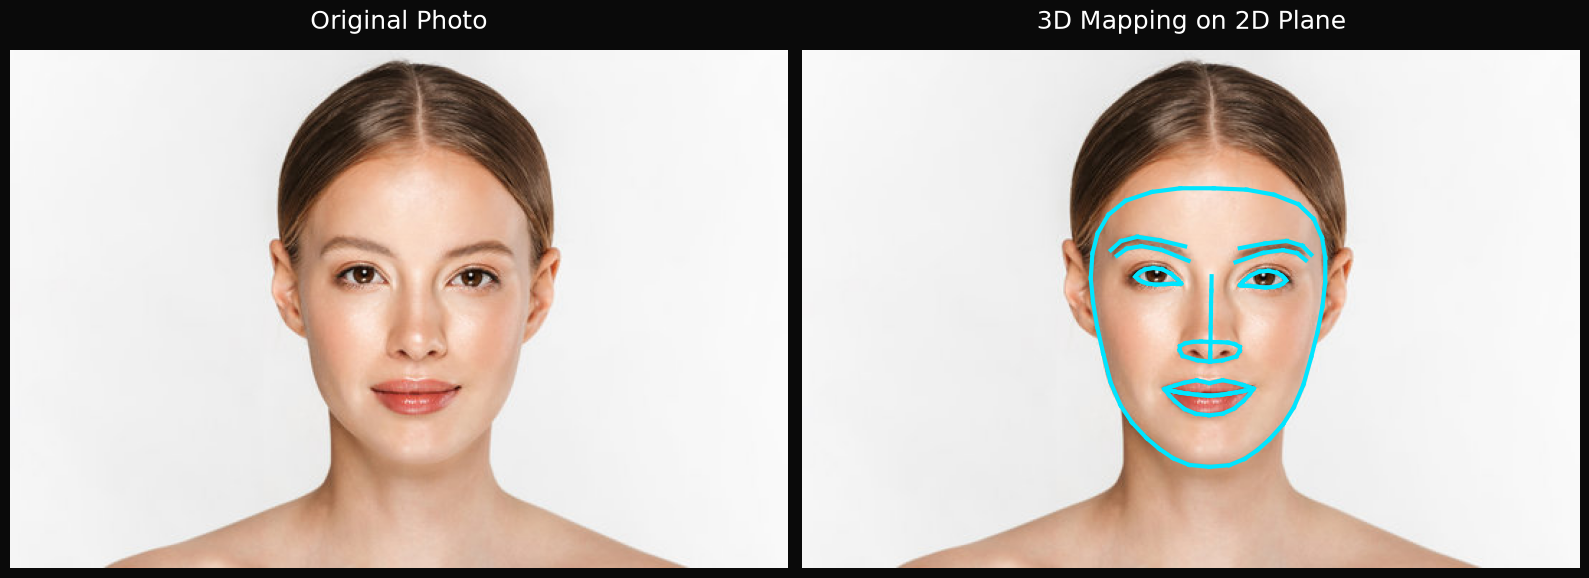

In [46]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 2D Plane Projection (Original vs Mapped)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0a0a0a')

img = mpimg.imread(USER_IMG_PATH)
image_h, image_w, _ = img.shape

# --- 1. Original Image ---
ax1.imshow(img)
ax1.axis('off')
ax1.set_title("Original Photo", color='white', fontsize=18, pad=15)

# --- 2. Mapped Image (3D wireframe flattened onto 2D photo) ---
ax2.imshow(img)
for connection_set in CONNECTIONS:
    for start_idx, end_idx in connection_set:
        # Convert normalized coordinates back to image pixel coordinates
        x1 = landmarks[start_idx].x * image_w
        y1 = landmarks[start_idx].y * image_h
        x2 = landmarks[end_idx].x * image_w
        y2 = landmarks[end_idx].y * image_h
        ax2.plot([x1, x2], [y1, y2], color='#00e5ff', linewidth=3, alpha=1.0)

ax2.axis('off')
ax2.set_title("3D Mapping on 2D Plane", color='white', fontsize=18, pad=15)

plt.tight_layout()
plt.show()
